In [1]:
import pandas as pd
merged=pd.read_csv('merged.csv')

In [2]:
pip install pytorch_tabnet

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

sentiment_map = {'positive': 1, 'neutral': 0, 'mixed': 0, 'negative': -1}
merged['Sentiment_Score'] = merged['Sentiment'].map(sentiment_map).fillna(0)

merged['Decayed_Sentiment'] = merged['Sentiment_Score'] / np.log1p(merged['News_Age_Minutes'] + 1)

merged['Target'] = (merged['Open'].shift(-1) > merged['Close']).astype(int)

features = [
    'RSI_14', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 
     'EMA_10', 'EMA_50', 'rolling_high_20',
    'kalman_close', 'kalman_diff', 'Decayed_Sentiment'
]


merged_clean = merged.dropna(subset=features + ['Target']).copy()

X = merged_clean[features].values
y = merged_clean['Target'].values

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.2)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

test_df = merged_clean.iloc[train_size+val_size:].copy()

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [ ]:

clf = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='sparsemax' 
)

clf.fit(
    X_train=X_train, y_train=y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_name=['train', 'valid'],
    eval_metric=['accuracy'],
    max_epochs=50, 
    patience=0,
    batch_size=1024, 
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")
C:\Users\abdur\AppData\Roaming\Python\Python313\site-packages\pytorch_tabnet\abstract_model.py:687: UserWarning: No early stopping will be performed, last training weights will be used.
  warnings.warn(wrn_msg)


epoch 0  | loss: 0.69128 | train_accuracy: 0.56323 | valid_accuracy: 0.57579 |  0:00:02s
epoch 1  | loss: 0.6837  | train_accuracy: 0.56658 | valid_accuracy: 0.57223 |  0:00:04s
epoch 2  | loss: 0.68317 | train_accuracy: 0.56529 | valid_accuracy: 0.57306 |  0:00:07s
epoch 3  | loss: 0.68285 | train_accuracy: 0.56547 | valid_accuracy: 0.57295 |  0:00:09s
epoch 4  | loss: 0.68279 | train_accuracy: 0.56658 | valid_accuracy: 0.57379 |  0:00:11s
epoch 5  | loss: 0.68232 | train_accuracy: 0.56439 | valid_accuracy: 0.57345 |  0:00:13s
epoch 6  | loss: 0.68246 | train_accuracy: 0.56388 | valid_accuracy: 0.57545 |  0:00:16s
epoch 7  | loss: 0.68173 | train_accuracy: 0.56645 | valid_accuracy: 0.57367 |  0:00:18s
epoch 8  | loss: 0.68212 | train_accuracy: 0.56648 | valid_accuracy: 0.57473 |  0:00:20s
epoch 9  | loss: 0.68125 | train_accuracy: 0.56806 | valid_accuracy: 0.57345 |  0:00:23s
epoch 10 | loss: 0.6815  | train_accuracy: 0.56737 | valid_accuracy: 0.57451 |  0:00:25s
epoch 11 | loss: 0.68

       STATISTICAL PERFORMANCE (50% THRESHOLD)
Test Accuracy: 56.58%

Classification Report:
               precision    recall  f1-score   support

Down/Flat (0)       0.58      0.90      0.71      5210
       Up (1)       0.44      0.11      0.18      3790

     accuracy                           0.57      9000
    macro avg       0.51      0.50      0.44      9000
 weighted avg       0.52      0.57      0.48      9000

Confusion Matrix:
[[4672  538]
 [3370  420]]

    FINANCIAL PERFORMANCE (>60.0% THRESHOLD)
Starting Capital:           $10,000.00
Total Trades Executed:      23
Profitable Trades:          19 (82.61%)

Gross Profit (Pre-Fees):    $218.60
Total Broker Fees Paid:     $4.69
Total Slippage Cost:        $410.17
Net Profit (Actual Money):  $213.91
Ending Account Equity:      $10,213.91
ROI over period:            2.14%


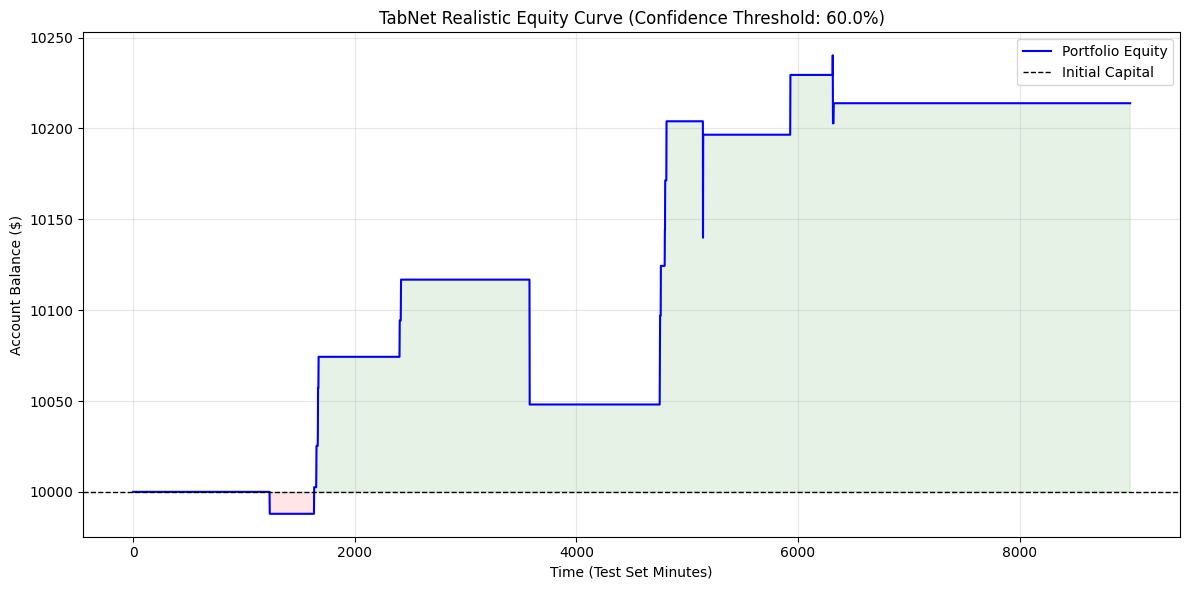

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("="*50)
print("       STATISTICAL PERFORMANCE (50% THRESHOLD)")
print("="*50)

y_pred_probs = clf.predict_proba(X_test)[:, 1] 
y_pred_base = (y_pred_probs > 0.50).astype(int)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred_base) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_base, target_names=['Down/Flat (0)', 'Up (1)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_base))


df_test = merged_clean.iloc[-len(y_pred_probs):].copy()

CONFIDENCE_THRESHOLD = 0.60
df_test['Prob_Up'] = y_pred_probs
df_test['Signal'] = (df_test['Prob_Up'] > CONFIDENCE_THRESHOLD).astype(int)


df_test['Exec_Open'] = df_test['Open'].shift(-1)
df_test['Exec_Close'] = df_test['Close'].shift(-1)

df_test = df_test.dropna(subset=['Exec_Open', 'Exec_Close']).copy()


print("\n" + "="*50)
print(f"    FINANCIAL PERFORMANCE (>{CONFIDENCE_THRESHOLD*100}% THRESHOLD)")
print("="*50)

STARTING_CAPITAL = 10000.0
FEE_PER_SHARE = 0.009  


df_test['Slippage_Per_Share'] = (df_test['Exec_Open'] - df_test['Close'])

df_test['Shares_Traded'] = np.where(
    df_test['Signal'] == 1, 
    np.floor(STARTING_CAPITAL / df_test['Exec_Open']), 
    0
)

df_test['Total_Slippage_Cost'] = df_test['Slippage_Per_Share'] * df_test['Shares_Traded']

df_test['Gross_PnL'] = np.where(
    df_test['Signal'] == 1, 
    (df_test['Exec_Close'] - df_test['Exec_Open']) * df_test['Shares_Traded'], 
    0
)

df_test['Fees'] = df_test['Shares_Traded'] * FEE_PER_SHARE


df_test['Net_PnL'] = df_test['Gross_PnL'] - df_test['Fees']

df_test['Equity'] = STARTING_CAPITAL + df_test['Net_PnL'].cumsum()

total_trades = df_test['Signal'].sum()
winning_trades = len(df_test[(df_test['Signal'] == 1) & (df_test['Net_PnL'] > 0)])
gross_profit = df_test['Gross_PnL'].sum()
total_fees = df_test['Fees'].sum()
total_slippage = df_test['Total_Slippage_Cost'].sum()
net_profit = df_test['Net_PnL'].sum()
final_equity = df_test['Equity'].iloc[-1]
roi = (net_profit / STARTING_CAPITAL) * 100

print(f"Starting Capital:           ${STARTING_CAPITAL:,.2f}")
print(f"Total Trades Executed:      {total_trades}")

if total_trades > 0:
    win_rate_post_fees = (winning_trades / total_trades) * 100
    print(f"Profitable Trades:          {winning_trades} ({win_rate_post_fees:.2f}%)")
else:
    print("No trades executed at this threshold.")
    
print(f"\nGross Profit (Pre-Fees):    ${gross_profit:,.2f}")
print(f"Total Broker Fees Paid:     ${total_fees:,.2f}")
print(f"Total Slippage Cost:        ${total_slippage:,.2f}")
print(f"Net Profit (Actual Money):  ${net_profit:,.2f}")
print(f"Ending Account Equity:      ${final_equity:,.2f}")
print(f"ROI over period:            {roi:.2f}%")


plt.figure(figsize=(12, 6))
plt.plot(range(len(df_test)), df_test['Equity'], color='blue', linewidth=1.5, label='Portfolio Equity')
plt.title(f'TabNet Realistic Equity Curve (Confidence Threshold: {CONFIDENCE_THRESHOLD*100}%)')
plt.ylabel('Account Balance ($)')
plt.xlabel('Time (Test Set Minutes)')
plt.axhline(STARTING_CAPITAL, color='black', linestyle='--', linewidth=1, label='Initial Capital')

plt.fill_between(range(len(df_test)), df_test['Equity'], STARTING_CAPITAL, 
                 where=(df_test['Equity'] >= STARTING_CAPITAL), color='green', alpha=0.1)
plt.fill_between(range(len(df_test)), df_test['Equity'], STARTING_CAPITAL, 
                 where=(df_test['Equity'] < STARTING_CAPITAL), color='red', alpha=0.1)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()